
===== STATISTICAL ANALYSIS =====
                                          Mean         Median           Mode  \
Year                               1999.064251    2002.000000    2002.000000   
Seq                                 722.789828     287.000000      19.000000   
Aid Contribution                   6207.961196     721.000000     721.000000   
Dis Mag Value                     15285.684823     161.000000     161.000000   
Start Year                         1999.076081    2002.000000    2000.000000   
Start Month                           6.440721       7.000000       7.000000   
Start Day                            15.173253      15.000000      15.000000   
End Year                           1999.129607    2002.000000    2000.000000   
End Month                             6.581443       7.000000       7.000000   
End Day                              15.829574      16.000000      16.000000   
Total Deaths                       1179.740006      18.000000      18.000000   
No Inj

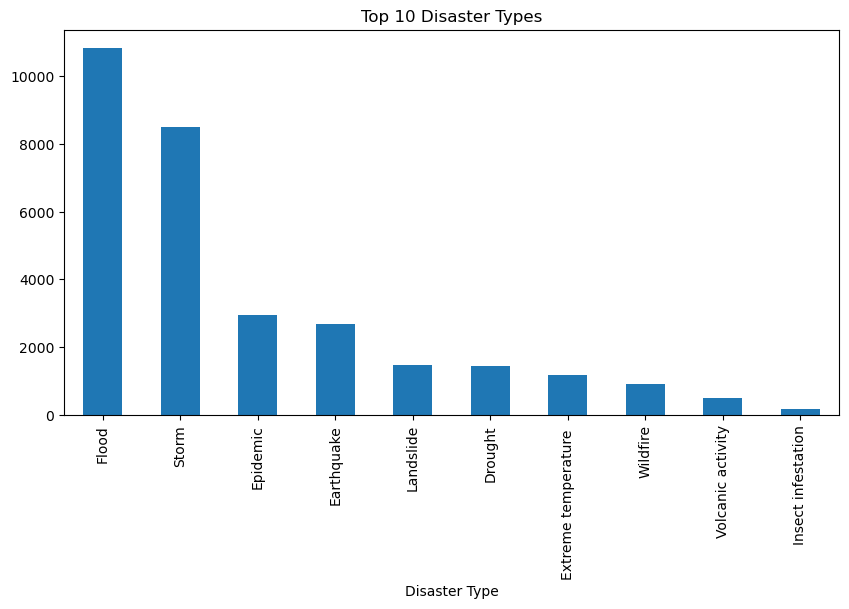

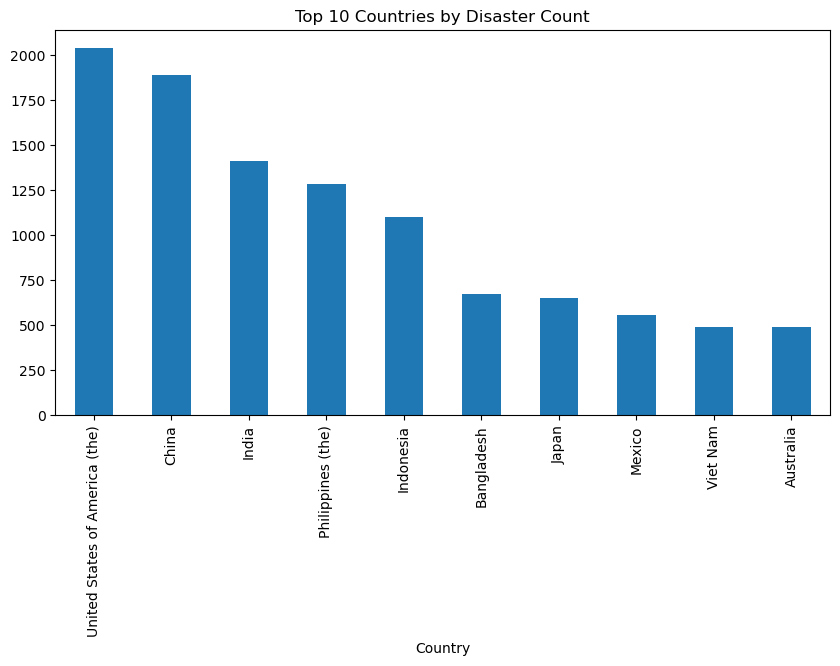

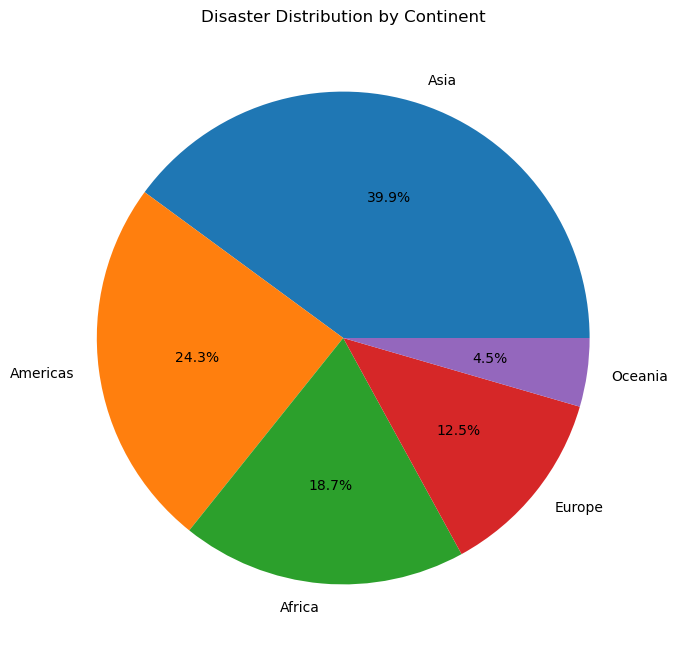

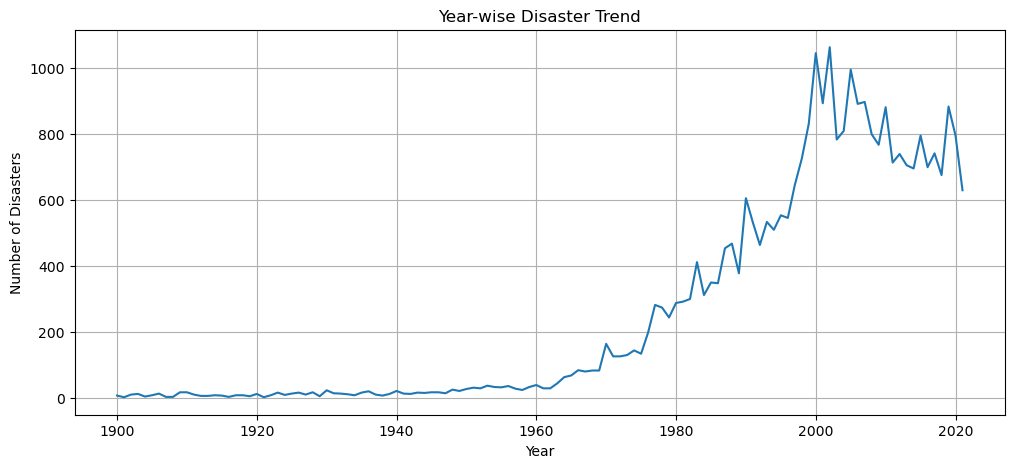

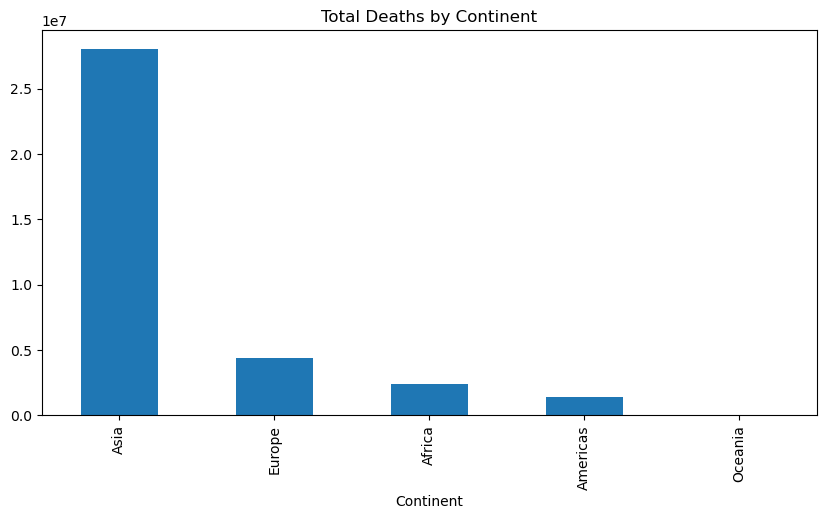

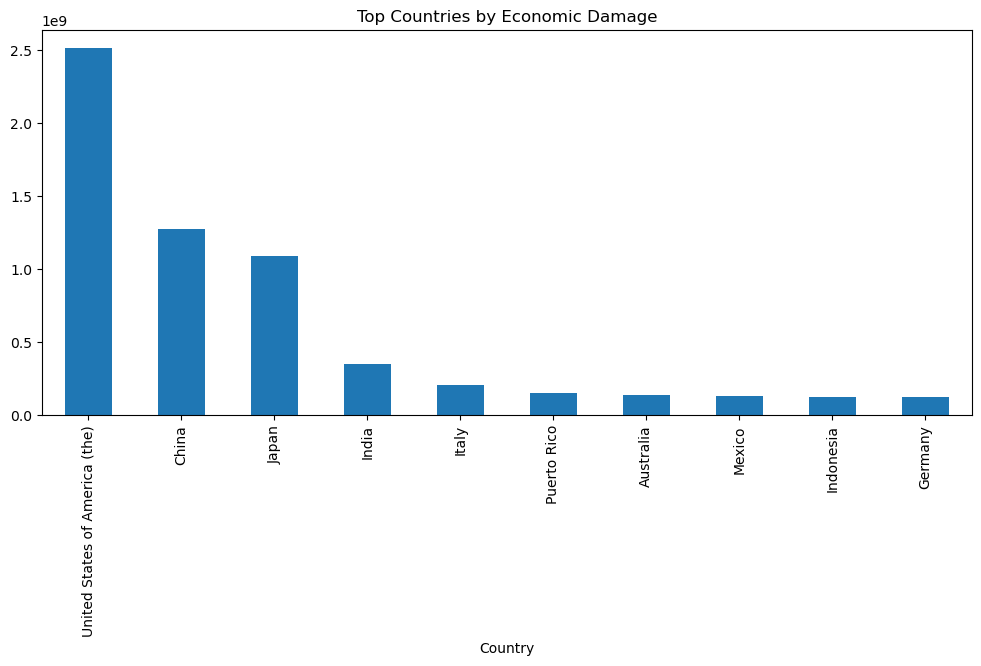

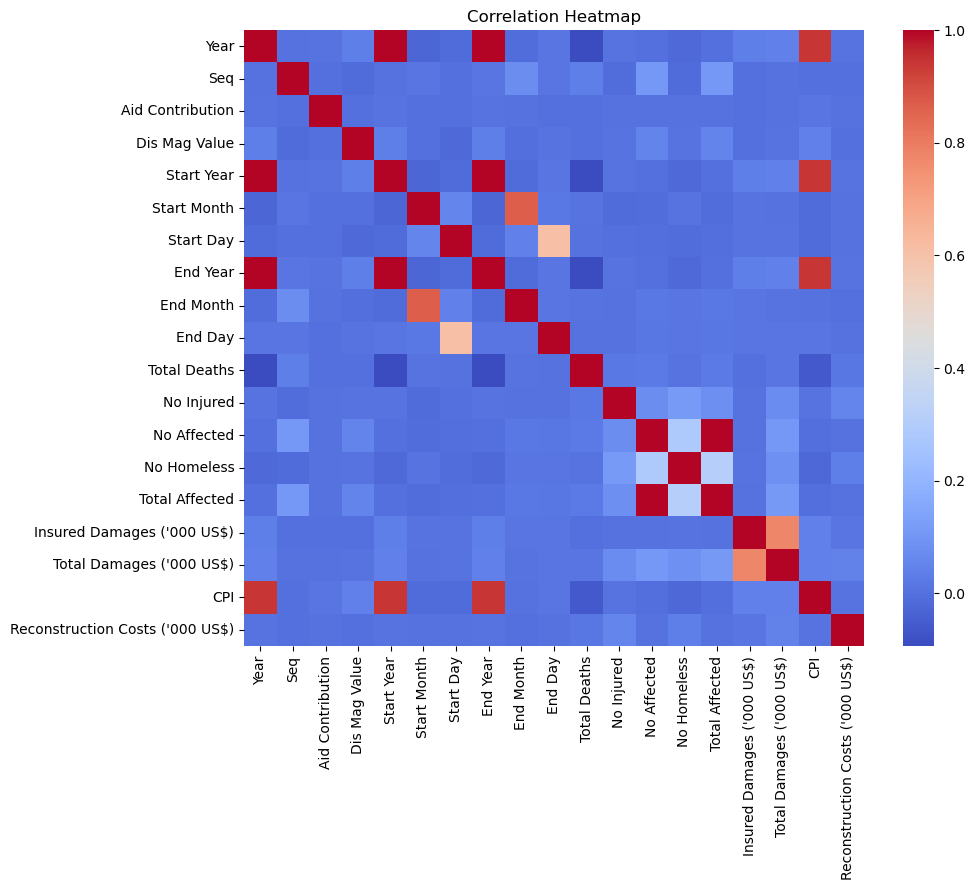


DATASET INSIGHTS
1. Most Common Disaster Type: Flood
2. Most Disaster-Prone Country: United States of America (the)
3. Most Affected Continent: Asia
4. Peak Disaster Year: 2002 with 1064 disasters
5. Deadliest Continent: Asia with 28,065,071 deaths
6. Highest Economic Loss: United States of America (the)
7. Floods and Storms together account for 62.80% of all disasters.

Files Saved Successfully


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load both datasets
df1 = pd.read_csv("1900_2021_DISASTERS.xlsx - emdat data.csv")
df2 = pd.read_csv("1970-2021_DISASTERS.xlsx - emdat data.csv")

# Combine datasets
df = pd.concat([df1, df2], ignore_index=True)

# Remove duplicate disaster records
df = df.drop_duplicates()

# Fill missing numeric values
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Basic Statistics
stats = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Mode": df[num_cols].mode().iloc[0],
    "Std Dev": df[num_cols].std()
})

print("\n===== STATISTICAL ANALYSIS =====")
print(stats)

# =====================
# INSIGHT 1
# =====================
top_disaster = df['Disaster Type'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_disaster.plot(kind='bar')
plt.title("Top 10 Disaster Types")
plt.show()

# =====================
# INSIGHT 2
# =====================
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Disaster Count")
plt.show()

# =====================
# INSIGHT 3
# =====================
continent_disasters = df['Continent'].value_counts()

plt.figure(figsize=(8,8))
continent_disasters.plot(kind='pie', autopct='%1.1f%%')
plt.title("Disaster Distribution by Continent")
plt.ylabel("")
plt.show()

# =====================
# INSIGHT 4
# =====================
yearly = df.groupby('Year').size()

plt.figure(figsize=(12,5))
yearly.plot()
plt.title("Year-wise Disaster Trend")
plt.ylabel("Number of Disasters")
plt.grid(True)
plt.show()

# =====================
# INSIGHT 5
# =====================
if 'Total Deaths' in df.columns:
    deaths = df.groupby('Continent')['Total Deaths'].sum()

    plt.figure(figsize=(10,5))
    deaths.sort_values(ascending=False).plot(kind='bar')
    plt.title("Total Deaths by Continent")
    plt.show()

# =====================
# INSIGHT 6
# =====================
damage_col = "Total Damages ('000 US$)"

if damage_col in df.columns:

    damage = (
        df.groupby('Country')[damage_col]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12,5))
    damage.plot(kind='bar')
    plt.title("Top Countries by Economic Damage")
    plt.show()

# =====================
# INSIGHT 7
# =====================
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# =====================
# GENERATED INSIGHTS
# =====================

print("\n" + "="*60)
print("DATASET INSIGHTS")
print("="*60)

print(f"1. Most Common Disaster Type: {df['Disaster Type'].value_counts().idxmax()}")

print(f"2. Most Disaster-Prone Country: {df['Country'].value_counts().idxmax()}")

print(f"3. Most Affected Continent: {df['Continent'].value_counts().idxmax()}")

print(f"4. Peak Disaster Year: {yearly.idxmax()} with {yearly.max()} disasters")

if 'Total Deaths' in df.columns:
    print(f"5. Deadliest Continent: {deaths.idxmax()} with {deaths.max():,.0f} deaths")

if damage_col in df.columns:
    print(f"6. Highest Economic Loss: {damage.idxmax()}")

floods = len(df[df['Disaster Type'] == 'Flood'])
storms = len(df[df['Disaster Type'] == 'Storm'])

print(
    f"7. Floods and Storms together account for "
    f"{((floods+storms)/len(df))*100:.2f}% of all disasters."
)

# Save outputs
df.to_csv("Combined_Cleaned_Disaster_Dataset.csv", index=False)
stats.to_csv("Statistical_Analysis.csv")

print("\nFiles Saved Successfully")